In [ ]:
from itables import show
import pandas as pd

df = pd.DataFrame({"A": range(100), "B": range(100, 200)})
show(df, scrollY="300px", scrollX=True)

In [ ]:
import plotly.express as px
import pandas as pd
df = pd.read_csv("data/results_catboost.csv")
fig = px.scatter(df, x="Actual", y="Predicted", color="Experiment")
fig.show()

In [ ]:
from upsetty import Upset
import pandas as pd

# create sample data ({'class_name': [boolean indicators]})
data = {
    'Class A': [True, True, True, False, False, True],
    'Class B': [True, True, True, True, True, False],
    'Class C': [False, False, False, True, True, True]
}

# convert sample data dict to pd.DataFrame
df = pd.DataFrame(data)
# create UpSet figure
upset = Upset.generate_plot(df)

# show the figure
upset.show()

In [ ]:
import pandas as pd
from upsetplot import from_memberships
import plotly.graph_objects as go

# Sample data
data = {
    'Class A': [True, True, True, False, False, True],
    'Class B': [True, True, True, True, True, False],
    'Class C': [False, False, False, True, True, True]
}

df = pd.DataFrame(data)

# Generate UpSet data
upset_data = from_memberships(df.values.tolist())

# Create the UpSet plot
fig = go.Figure()

# Add bars for set intersections
for i, (index, value) in enumerate(upset_data.items()):
    fig.add_trace(go.Bar(
        x=[i],
        y=[value],
        name=str(index),
        customdata=[index],
        hovertemplate='Intersection: %{customdata}<br>Count: %{y}'
    ))

# Customize layout
fig.update_layout(
    title='Interactive UpSet Plot',
    xaxis_title='Set Intersections',
    yaxis_title='Count',
    showlegend=False
)

# Add interactivity
fig.update_traces(
    marker_color='rgb(158,202,225)',
    marker_line_color='rgb(8,48,107)',
    marker_line_width=1.5,
    opacity=0.6
)

# Show the plot
fig.show()



In [ ]:
upset = Upset.generate_plot(
    
    # sample data
    df,

    # change category colors to a light blue, green, and yellow
    categories_colors=['#3987CA', '#FFC300', '#39CA41'],

    # change the category label color to a dark black
    categorylabel_color='#2F2F2F',

    # change the bar intersect color to a soft black
    bar_intersect_color='#454545',

    # change the marker line color to a soft black
    markerline_color='#454545'
)

In [ ]:
data = {
    'Class A': [True, True, False, False, True, True, False],
    'Class B': [True, False, True, False, True, False, True],
    'Class C': [True, False, False, True, False, True, True],

    # adding a column 'Value' of non-boolean numbers
    'Value': [1, 2, 3, 4, 5, 6, 7]
}

df = pd.DataFrame(data)

upset = Upset.generate_plot(df, 'Value')
upset.show()

In [1]:
from upsetplot import generate_counts
from upsetplot import plot
from matplotlib import pyplot
from upsetplot import from_memberships
from upsetplot import from_contents
import pandas as pd
lfc_intersections_df = pd.read_csv("data/Intersection_Genes.csv", index_col=0).drop_duplicates()
result_subset = {}

# Iterate over columns to extract genes marked as True
for col in lfc_intersections_df.columns:
    # Filter genes where the column value is True
    genes = lfc_intersections_df.index[lfc_intersections_df[col] == True].tolist()
    # Add the list to the dictionary with the column name as the key
    result_subset[col] = genes
upset_data = from_contents(result_subset)


/home/karen/Documents/GitHub/shinny/.venv/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


In [6]:
import json
result_subset = json.load( open( "data/result_subset.json" ) )

In [7]:
upset_data = from_contents(result_subset)


/home/karen/Documents/GitHub/shinny/.venv/lib/python3.11/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


/home/karen/Documents/GitHub/shinny/.venv/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/karen/Documents/GitHub/shinny/.venv/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

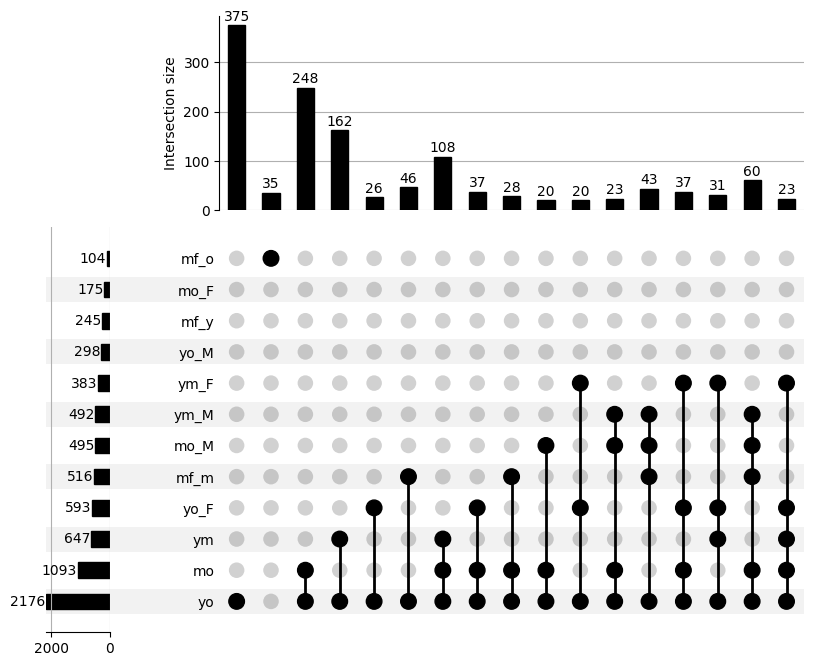

In [8]:
plot(upset_data, min_subset_size=20, show_counts=True)